In [1]:
# PACKAGES

import random, time, pickle
from datetime import datetime
from matplotlib import pyplot as plt
import numpy as np
import networkx as nx
from model import *
from analytics import period, onset

In [2]:
# FIGURE SETTINGS

alphabet = ['(' + _ +')' for _ in 'abcdefghijklmnopqrstuvwxyz']
blues = [plt.cm.PuBu(1-val) for val in [0.0, 0.25, 0.50, 0.75]]
greens = [plt.cm.YlGn(val) for val in [0.25,0.5,0.75,1.0]]

plt.rcParams["font.family"] = "Arial"
plt.rcParams['mathtext.fontset'] = "custom"
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.bf'] = 'Arial:bold'
plt.rcParams['axes.linewidth'] = 0.5
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

In [3]:
# SET CONFIGURATIONS

# Set social graph
n = 100
complete_graph=True

# Simulation time and resolution
tmax = 3000
time_step=0.01

# Set model parameters
threshold_x = 0.5

# Set seed
seed = 100

# Set parameter grid: population means for internal attitudes and initial nudge effects
# set mean values for internal attitudes
alpha_mean = np.arange(0,0.55,0.05)
# set mean values for initial nudge values
mean_y0=[0, 0.25, 0.5, 0.75]

In [4]:
# PROCESS CONFIGURATIONS

# Create adjacency matrix
if complete_graph:
    A = np.ones((n,n))-np.eye(n) 
else:
    A = np.random.choice([1, 0], size=(n, n)) 
    A = A - np.diag(np.diag(A))

In [6]:
# LOAD OR GENERATE AND SAVE DATA

load = True
file_loc = 'data/data-for-figure-3.p'
   
if load:
    all_alphas, all_freqs, all_starttimes = pickle.load(open(file_loc, 'rb'))
    
else:

    t2=time.time()
    np.random.seed(seed)
    
    # SET INITIAL CONDITIONS
    
    # initial condition for intentions x
    x0 = np.random.uniform(size=n)*0.25

    # initial conditions for nudge effects y
    y0 = [np.ones(n)*mean_y0[0], 
          np.random.uniform(low=-1, high=1, size=n)*0.25 + mean_y0[1], 
          np.random.uniform(low=-1, high=1, size=n)*0.25 + mean_y0[2],
          np.random.uniform(low=-1, high=1, size=n)*0.25 + mean_y0[3]]

    # INITIALIZE DATA ARRAYS
    all_alphas = np.zeros((len(y0),len(alpha_mean),n))
    all_freqs = np.zeros((len(y0),len(alpha_mean),n))
    all_starttimes = np.zeros((len(y0),len(alpha_mean),n))

    # GENERATE DATA
    for i in range(len(y0)):

        # build initial condition
        X0 = np.concatenate([x0,y0[i]])

        for run in range(len(alpha_mean)):

            # set alphas
            alphas = np.random.uniform(low=-0.5, high=0.5, size=n) + alpha_mean[run]

            # make system
            system = make_system(A, alphas, shiftS=-0.5, shiftC=0.5, scaleC=0.05,
                growth='symlogistic', threshold_x=threshold_x, 
                immediacy_parameter=0.02)

            # INTEGRATE
            t_, x_, y_ = integrate_system(system, t_max=tmax, time_step=0.01, max_events=1E3, X0=X0)

            # GET PERIODS
            periods = np.array([period(x_[i_], dt=time_step, cutoff=0.99*threshold_x) for i_ in range(n)])
            onsets = np.array([onset(x_[i_], dt=time_step, cutoff=0.99*threshold_x) for i_ in range(n)])
            frequencies = np.nan_to_num(1/periods)

            all_alphas[i, run] = np.copy(alphas)
            all_starttimes[i, run] = np.copy(onsets)
            all_freqs[i, run] = np.copy(frequencies)

    # SAVE DATA
    pickle.dump([all_alphas, all_freqs, all_starttimes], open(file_loc, 'wb'))
    
    print(time.time()-t2)

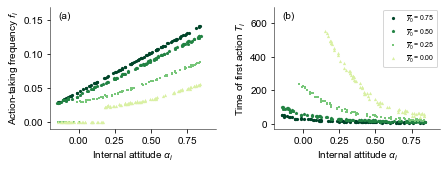

In [7]:
# PLOT FIGURE
fig = plt.figure(figsize=(7,2.25))

ax1 = plt.subplot(1,2,1)

ax1.set_xlabel(r'Internal attitude $\alpha_i$')
ax1.set_ylabel(r'Action-taking frequency $f_i$', labelpad=2)
ax1.text(0.05, 0.9, alphabet[0], transform=ax1.transAxes)

plt.ylim([-0.01,0.17])
ax1.set_yticks([0, 0.05, 0.1, 0.15])
plt.xlim([-0.2,0.95])
ax1.set_xticks([0, .25, .5, .75])

labels = [r'$\overline{y}_0=%.2f$' % _ for _ in mean_y0]

for i in range(len(all_starttimes)):
    sorted_alphas = [a_ for a_ in sorted(all_alphas[i][-4])]
    sorted_starttimes = [s_ for _,s_ in sorted(zip(all_alphas[i][-4], all_starttimes[i][-4]))]
    ax1.plot(sorted_alphas, sorted_starttimes, '^spo'[i], alpha=1,
        ms=0.8*[4,3.5,4.5,4][i], label=labels[i], zorder=10-i,
        mfc=greens[i], mec='white', mew=0.0)     
    


ax2 = plt.subplot(1,2,2)

ax2.set_xlabel(r'Internal attitude $\alpha_i$')
ax2.set_ylabel(r'Time of first action $T_i$', labelpad=2)
ax2.text(0.05, 0.9, alphabet[1], transform=ax2.transAxes)

plt.ylim([-30,700])
ax2.set_yticks([0, 200, 400, 600])
plt.xlim([-0.2,0.95])
ax2.set_xticks([0, .25, .5, .75])

for i in range(len(all_freqs)):
    sorted_alphas = [a_ for a_ in sorted(all_alphas[i][-4])]
    sorted_freqs = [f_ for _,f_ in sorted(zip(all_alphas[i][-4], all_freqs[i][-4]))]
    ax2.plot(sorted_alphas, sorted_freqs, '^spo'[i], alpha=1,
        ms=0.8*[4,3.5,4.5,4][i], label=labels[i], zorder=10-i,
        mfc=greens[i], mec='white', mew=0.0)   





plt.subplots_adjust(hspace=0.1, wspace=0.35)

# Get the current date-time string
current_datetime = datetime.now()
dts = current_datetime.strftime("%Y-%m-%d_%H.%M.%S")

# save figure with current date and time
plt.savefig('figures/figure-3_'+dts+'.pdf', bbox_inches="tight")